# Flight Ticket Price Prediction

##  <b><font color= 'red'> Problem Statement </font></b>
- Flight ticket prices change frequently and are difficult to predict.
- Prices depend on factors such as airline, source, destination, duration, stops, and journey date.
- The goal is to analyze historical flight data and identify factors affecting ticket prices.
- Build a Machine Learning model to accurately predict future flight fares.
- Help customers plan their travel and booking decisions more effectively.

## <b><font color= 'red'> Objective </font></b>
- Perform Exploratory Data Analysis (EDA) on flight fare dataset.
- Identify important factors affecting ticket prices.
- Clean and preprocess the dataset.
- Perform feature engineering.
- Build multiple machine learning models.
- Compare model performance.
- Apply hyperparameter tuning.
- Select the best model for production.

### <font color='green'> Importing some important libraries </font>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

### <font color='green'> EDA (Exploratory Data Analysis) </font>

In [2]:
# storing the data into a variable
df = pd.read_excel("Flight_Fare.xlsx")

In [3]:
#check first 10 records
df.head(10)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,No info,3873
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,No info,8625


In [4]:
#check last 5 records
df.tail(5)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
df.shape

(10683, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [7]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [8]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [9]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

### Observation
- Dataset contains airline, route, duration, stops and price information.
- Some columns contain missing values.
- Price is the target variable.

In [10]:
df.dropna(inplace=True)

In [11]:
# After Handling Missing Values
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

### Observation
- The dataset contained only 2 missing values :-
     - 1 value in Route column and 1 value in Total_Stops column.
Since the number of missing records was negligible compared to the total dataset size, these rows were removed using dropna(). This ensured data quality without significantly affecting the dataset.

In [12]:
# Feature Engineering
# Date of Journey

df["Journey_Day"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.day

df["Journey_Month"] = pd.to_datetime(df["Date_of_Journey"], format="%d/%m/%Y").dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)

### Observation
- Extracted Journey Day and Journey Month from Date_of_Journey.
- Helps identify the impact of travel dates and seasons on ticket prices.
- Original date column was removed after extraction.

In [13]:
# Departure Time
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

df["Dep_Min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop("Dep_Time", axis=1, inplace=True)

### Observation
- Extracted Departure Hour and Departure Minute from Dep_Time.
- Flight prices may vary based on departure timing.
- Original departure time column was removed.

In [14]:
# Arrival Time
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

df["Arrival_Min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)

### Observation
- Extracted Arrival Hour and Arrival Minute from Arrival_Time.
- Helps analyze the effect of arrival timing on fare prices.
- Original arrival time column was removed.

In [15]:
# Duration
duration = list(df["Duration"])

In [16]:
for i in range(len(duration)):
    
    if len(duration[i].split()) != 2:
        
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

In [17]:
hours = []
mins = []

for i in range(len(duration)):
    
    hours.append(int(duration[i].split("h")[0]))
    
    mins.append(int(duration[i].split("m")[0].split()[-1]))

In [18]:
df["Duration_Hours"] = hours
df["Duration_Minutes"] = mins

df.drop("Duration", axis=1, inplace=True)

### Observation
- Converted duration from text format (e.g., 2h 50m) into numerical features.
- Created Duration_Hours and Duration_Minutes columns.
- Numerical duration features improve model performance and interpretation.

# <font color='red'>Visualization</font>

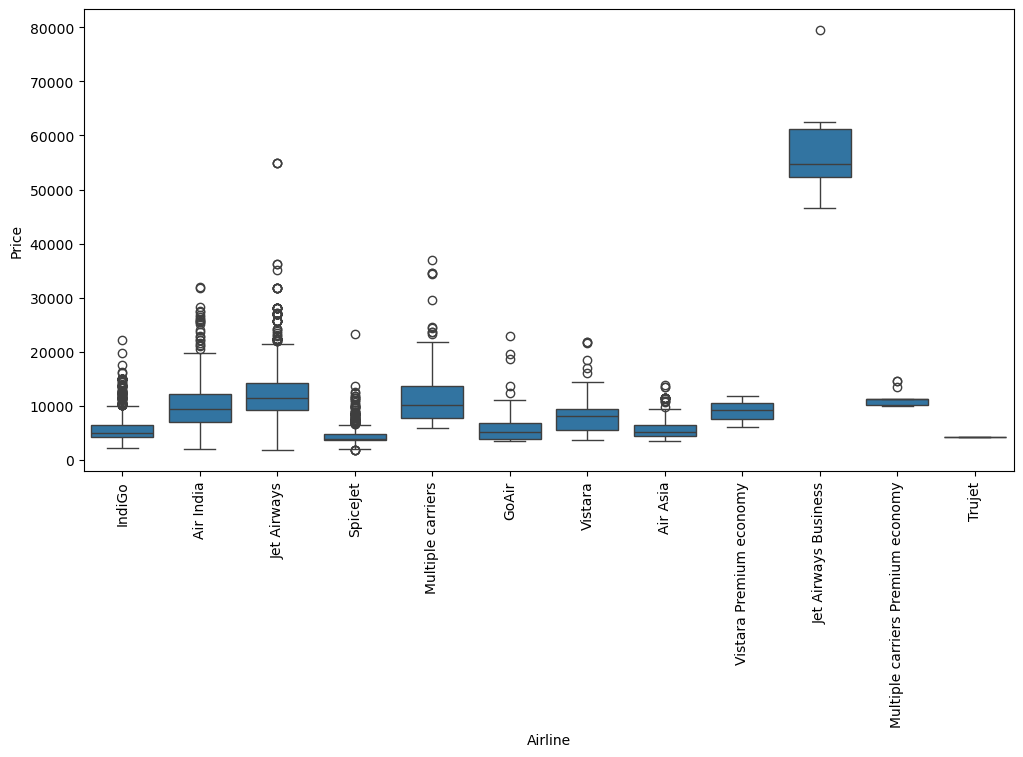

In [19]:
# Airline vs Price
plt.figure(figsize=(12,6))
sns.boxplot(x="Airline", y="Price", data=df)
plt.xticks(rotation=90)
plt.show()

### Observation
- Jet Airways flights have higher median prices.
- Indigo flights are comparatively cheaper.
- Airline significantly impacts ticket price.

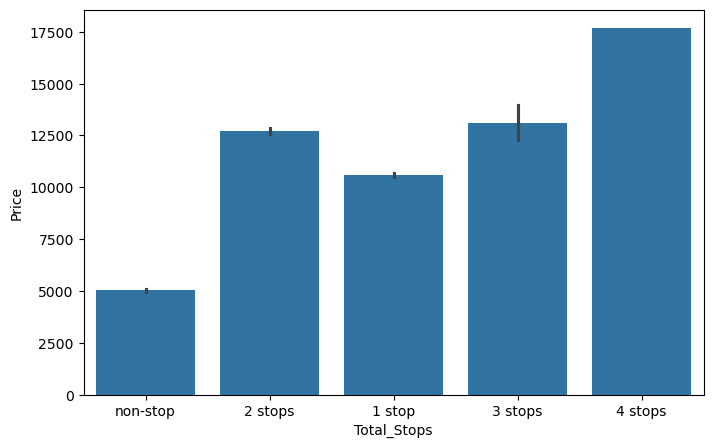

In [20]:
# Total Stops vs Price
plt.figure(figsize=(8,5))
sns.barplot(x="Total_Stops", y="Price", data=df)
plt.show()

### Observation
- Ticket prices increase as the number of stops increases.
- Non-stop flights generally have lower fares.

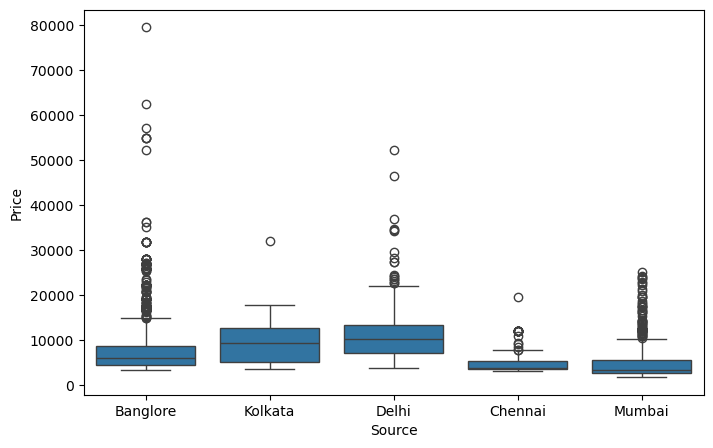

In [21]:
# Source vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x="Source", y="Price", data=df)
plt.show()

### Observation
- Delhi source flights show higher price variability.
- Flight origin affects fare significantly.

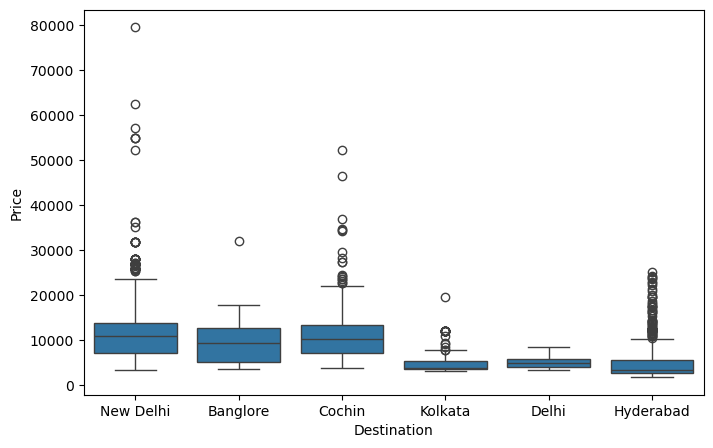

In [22]:
# Destination vs Price
plt.figure(figsize=(8,5))
sns.boxplot(x="Destination", y="Price", data=df)
plt.show()

### Observation
- Different destinations have different fare ranges.
- Destination is an important predictor.

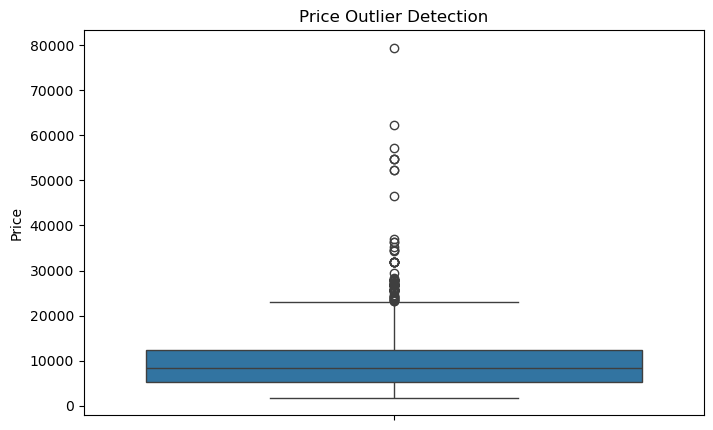

In [23]:
#Outlier Detection & Treatment
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Price"])
plt.title("Price Outlier Detection")
plt.show()

### Observation
- The Price column contains some extreme values (outliers).
- These outliers represent very expensive flight tickets compared to the majority of observations.
- Outliers can affect model performance, especially Linear Regression.
- Tree-based models like Random Forest are generally less sensitive to outliers.

In [49]:
# Remove Outliers Using IQR Method
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Price"] >= lower_bound) &
        (df["Price"] <= upper_bound)]

outliers.head()

,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Duration_Hours,Duration_Minutes
0,0,3897,24,3,22,20,1,10,2,50
1,2,7662,1,5,5,50,13,15,7,25
2,2,13882,9,6,9,25,4,25,19,0
3,1,6218,12,5,18,5,23,30,5,25
4,1,13302,1,3,16,50,21,35,4,45


## Observation
- Extreme fare values were removed using the IQR method.
- The dataset became more balanced.
- Removing outliers helps improve model stability and prediction accuracy.
- The impact is especially noticeable for Linear Regression and Decision Tree models.

### Use IQR for outlier detection
- IQR is simple and effective for skewed numerical data.
- It identifies extreme values without being affected by the outliers themselves.
- It helps improve model performance by reducing the influence of abnormal observations.

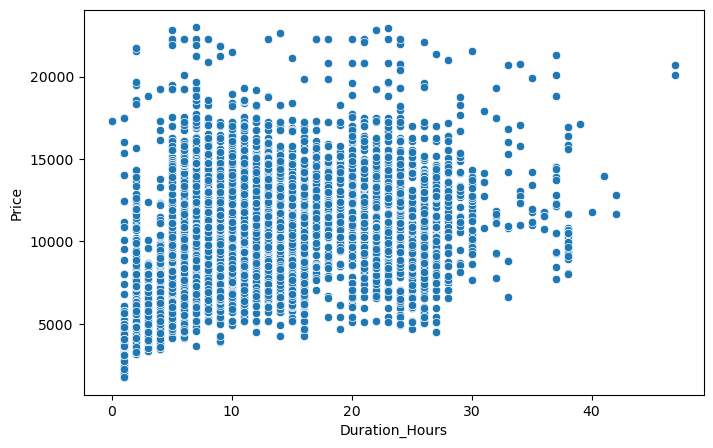

In [25]:
# Duration vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x="Duration_Hours", y="Price", data=df)
plt.show()

### Observation
- Longer flights tend to cost more.
- Positive relationship between duration and fare.

In [26]:
# Label Encoding
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})

In [27]:
airline = pd.get_dummies(df["Airline"], drop_first=True)

source = pd.get_dummies(df["Source"], drop_first=True)

destination = pd.get_dummies(df["Destination"], drop_first=True)

In [28]:
df.drop(["Airline","Source","Destination","Route","Additional_Info"], axis=1, inplace=True)

In [29]:
data = pd.concat([df, airline, source, destination], axis=1)

### Observation
- Categorical variables were converted into numerical format using One-Hot Encoding and mapping techniques. 
- This transformation made the data suitable for machine learning models and helped improve prediction accuracy.

In [30]:
# Train Test Split
X = data.drop("Price", axis=1)

y = data["Price"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# <font color='red'>Model Building</font>

## <font color='Green'>Linear Regression</font>

In [32]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### Why Linear Regression?
- Simple baseline model.
- Easy to interpret.
- Useful for understanding linear relationships.

## <font color='Green'>Decision Tree Regressor</font>

In [33]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

### Why Decision Tree?
- Captures non-linear relationships.
- Easy to visualize and explain.

## <font color='Green'>Random Forest Regressor</font>

In [34]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### Why Random Forest?
- Reduces overfitting.
- Higher accuracy.
- Ensemble learning

# <font color='Red'>Hyperparameter Tuning</font>

In [35]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

In [36]:
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [37]:
grid.fit(X_train,y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [38]:
grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

In [39]:
best_rf = grid.best_estimator_

In [40]:
rf_tuned_pred = best_rf.predict(X_test)

In [41]:
print("R2 Score :", r2_score(y_test, rf_tuned_pred))
print("MAE :", mean_absolute_error(y_test, rf_tuned_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_tuned_pred)))

R2 Score : 0.830801487558599
MAE : 1174.5745649835235
RMSE : 1664.9719816323106


### Observation
- Hyperparameter tuning improved the performance of the Random Forest model.
- The tuned model achieved a higher R² score and lower prediction error compared to other models.
- Tuned Random Forest provided the most accurate flight fare predictions.
- Therefore, it was selected as the final model for production deployment.

# <font color='red'>Model Evaluation</font>

## <font color='Green'>Evaluation Function</font>

In [42]:
def evaluate(y_test,pred):
    
    print("MAE :",mean_absolute_error(y_test,pred))
    
    print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))
    
    print("R2 :",r2_score(y_test,pred))

In [43]:
evaluate(y_test,lr_pred)

MAE : 1822.6149784933098
RMSE : 2432.606220723123
R2 : 0.6388178262787993


In [44]:
evaluate(y_test,dt_pred)

MAE : 1309.697190745987
RMSE : 2177.016800687631
R2 : 0.7107281036352295


In [45]:
evaluate(y_test,rf_pred)

MAE : 1125.068204035669
RMSE : 1740.2296648486176
R2 : 0.8151600609701042


In [46]:
evaluate(y_test,rf_tuned_pred)

MAE : 1174.5745649835235
RMSE : 1664.9719816323106
R2 : 0.830801487558599


# <font color='Red'>Model Comparison Report</font>

## <font color='Green'>Compare Models</font>

In [47]:
comparison = pd.DataFrame({
    
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    
    "R2 Score":[
        r2_score(y_test,lr_pred),
        r2_score(y_test,dt_pred),
        r2_score(y_test,rf_pred),
        r2_score(y_test,rf_tuned_pred)
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.638818
1,Decision Tree,0.710728
2,Random Forest,0.815160
3,Tuned Random Forest,0.830801


## Challenges Faced 
- Missing values were present in the Route and Total_Stops columns.
- Duration data was available in text format (e.g., 2h 50m) and required conversion into numerical features.
- Date and time columns could not be directly used for machine learning models.
- Categorical variables such as Airline, Source, and Destination needed encoding.
- Presence of outliers in the Price column could affect model performance.
- Selecting the most suitable model among multiple algorithms was challenging.
- Hyperparameter tuning was required to improve model accuracy.

## Suggestions
- Include real-time flight booking data for better predictions.
- Add features such as holiday season, festivals, and weather conditions.
- Use advanced algorithms like XGBoost or LightGBM for improved performance.
- Deploy the model using Streamlit or Flask for real-time predictions.
- Continuously retrain the model with updated flight fare data.
- Integrate airline demand and seat availability information.

## <font color='Red'>Conclusion</font>
- Flight ticket prices are influenced by factors such as airline, source, destination, duration, and total stops.
- Feature engineering and data preprocessing improved data quality and model performance.
- Multiple machine learning models were developed and evaluated.
- Hyperparameter tuning enhanced the performance of the Random Forest model.
- Random Forest achieved the best prediction accuracy among all models.
- The final model can help customers estimate future flight prices and plan their travel more effectively.
- The project successfully met the objective of predicting flight fares using machine learning techniques.